# Extração de Resultados (Tabelas e Gráficos)
Este notebook demonstra o processo de extração e formatação dos dados para gerar as tabelas e gráficos do artigo.

## 1. Carregamento dos Dados
Carregamos os dados originais (incluindo a métrica AUC).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

df = pd.read_csv('outputs/GreenAI_Outputs/resultados_folds.csv')
display(df.head())

,Model,Fold,Energy Consumption (kWh),Carbon Emissions (kg CO2),CPU Usage (kWh),Memory Usage (kWh),Accuracy,F1 Score,Precision,Recall,AUC
0,Decision Tree,1,0.000024,0.000002,0.000005,0.000019,0.683571,0.761132,0.664262,0.891080,0.722127
1,Random Forest,1,0.000068,0.000007,0.000047,0.000021,0.688799,0.764339,0.668630,0.892026,0.741295
2,Logistic Regression,1,0.000017,0.000002,0.000007,0.000010,0.687564,0.743702,0.693888,0.801222,0.726333
3,XGBoost,1,0.000199,0.000020,0.000145,0.000054,0.712633,0.767416,0.707824,0.837966,0.771690
4,Decision Tree,2,0.000017,0.000002,0.000004,0.000013,0.675984,0.753608,0.660503,0.877268,0.716648


## 2. Tratamento e Renomeação
Renomeamos as colunas para os nomes desejados e separamos entre métricas de performance e métricas de recursos.

In [3]:
rename_dict = {
    'Energy Consumption (kWh)': 'Energy (kWh)',
    'Carbon Emissions (kg CO2)': 'CO2 (kg)',
    'CPU Usage (kWh)': 'CPU (kWh)',
    'Memory Usage (kWh)': 'Memory (kWh)',
    'F1 Score': 'F1-score'
}
df = df.rename(columns=rename_dict)

metrics_cols = ['Accuracy', 'AUC', 'F1-score', 'Precision', 'Recall']
resources_cols = ['Energy (kWh)', 'CO2 (kg)', 'CPU (kWh)', 'Memory (kWh)']

df = df[['Model', 'Fold'] + metrics_cols + resources_cols]
display(df.head())

,Model,Fold,Accuracy,AUC,F1-score,Precision,Recall,Energy (kWh),CO2 (kg),CPU (kWh),Memory (kWh)
0,Decision Tree,1,0.683571,0.722127,0.761132,0.664262,0.891080,0.000024,0.000002,0.000005,0.000019
1,Random Forest,1,0.688799,0.741295,0.764339,0.668630,0.892026,0.000068,0.000007,0.000047,0.000021
2,Logistic Regression,1,0.687564,0.726333,0.743702,0.693888,0.801222,0.000017,0.000002,0.000007,0.000010
3,XGBoost,1,0.712633,0.771690,0.767416,0.707824,0.837966,0.000199,0.000020,0.000145,0.000054
4,Decision Tree,2,0.675984,0.716648,0.753608,0.660503,0.877268,0.000017,0.000002,0.000004,0.000013


## 3. Geração da Tabela 1: Resultados Detalhados por Fold (Apêndice)
Agrupa os resultados dos folds e calcula a Média (MEAN) no final do bloco de cada modelo.

In [4]:
def format_detailed_table(df):
    df_detailed = df.copy()
    means = df_detailed.groupby('Model')[metrics_cols + resources_cols].mean().reset_index()
    means['Fold'] = 'MEAN'
    df_final = pd.concat([df_detailed, means], ignore_index=True)
    df_final['Fold_Sort'] = df_final['Fold'].apply(lambda x: 999 if x == 'MEAN' else int(x))
    df_final = df_final.sort_values(by=['Model', 'Fold_Sort']).drop(columns=['Fold_Sort']).reset_index(drop=True)
    return df_final

df_detailed = format_detailed_table(df)
display(df_detailed)

,Model,Fold,Accuracy,AUC,F1-score,Precision,Recall,Energy (kWh),CO2 (kg),CPU (kWh),Memory (kWh)
0,Decision Tree,1,0.683571,0.722127,0.761132,0.664262,0.891080,0.000024,0.000002,0.000005,0.000019
1,Decision Tree,2,0.675984,0.716648,0.753608,0.660503,0.877268,0.000017,0.000002,0.000004,0.000013
2,Decision Tree,3,0.683147,0.727139,0.748044,0.677458,0.835051,0.000018,0.000002,0.000004,0.000014
3,Decision Tree,4,0.681500,0.720928,0.747082,0.676074,0.834758,0.000018,0.000002,0.000004,0.000014
4,Decision Tree,5,0.680224,0.721459,0.745612,0.677659,0.828711,0.000022,0.000002,0.000005,0.000017
5,Decision Tree,MEAN,0.680885,0.721660,0.751096,0.671191,0.853374,0.000020,0.000002,0.000004,0.000015
6,Logistic Regression,1,0.687564,0.726333,0.743702,0.693888,0.801222,0.000017,0.000002,0.000007,0.000010
7,Logistic Regression,2,0.680142,0.720404,0.739664,0.684527,0.804460,0.000020,0.000002,0.000009,0.000011
8,Logistic Regression,3,0.686646,0.728939,0.743514,0.689778,0.806329,0.000018,0.000002,0.000006,0.000011
9,Logistic Regression,4,0.676437,0.717111,0.735050,0.682418,0.796479,0.000019,0.000002,0.000007,0.000012


## 4. Geração da Tabela 2: Resumo (Média ± Desvio Padrão)
Calcula a média e o desvio padrão (amostral) das métricas de cada modelo.

In [5]:
def generate_summary_table(df):
    means = df.groupby('Model')[metrics_cols + resources_cols].mean()
    stds = df.groupby('Model')[metrics_cols + resources_cols].std(ddof=1)
    
    summary_df = pd.DataFrame(index=metrics_cols + resources_cols)
    for model in means.index:
        col_data = []
        for metric in summary_df.index:
            mean_val = means.loc[model, metric]
            std_val = stds.loc[model, metric]
            if metric in metrics_cols:
                col_data.append(f"{mean_val:.4f} \\pm {std_val:.4f}")
            else:
                col_data.append(f"{mean_val:.2e} \\pm {std_val:.2e}")
        summary_df[model] = col_data
    return summary_df

df_summary = generate_summary_table(df)
display(df_summary)

,Decision Tree,Logistic Regression,Random Forest,XGBoost
Accuracy,0.6809 \pm 0.0030,0.6829 \pm 0.0046,0.6844 \pm 0.0036,0.7123 \pm 0.0018
AUC,0.7217 \pm 0.0037,0.7231 \pm 0.0047,0.7392 \pm 0.0041,0.7688 \pm 0.0029
F1-score,0.7511 \pm 0.0064,0.7406 \pm 0.0035,0.7615 \pm 0.0023,0.7675 \pm 0.0009
Precision,0.6712 \pm 0.0082,0.6881 \pm 0.0046,0.6641 \pm 0.0036,0.7059 \pm 0.0033
Recall,0.8534 \pm 0.0286,0.8019 \pm 0.0038,0.8926 \pm 0.0007,0.8409 \pm 0.0040
Energy (kWh),2.00e-05 \pm 3.08e-06,1.95e-05 \pm 3.12e-06,7.33e-05 \pm 1.14e-05,2.03e-04 \pm 9.95e-06
CO2 (kg),1.96e-06 \pm 3.03e-07,1.92e-06 \pm 3.07e-07,7.21e-06 \pm 1.12e-06,2.00e-05 \pm 9.79e-07
CPU (kWh),4.46e-06 \pm 7.22e-07,7.66e-06 \pm 1.21e-06,5.00e-05 \pm 8.83e-06,1.49e-04 \pm 7.19e-06
Memory (kWh),1.55e-05 \pm 2.36e-06,1.18e-05 \pm 2.12e-06,2.33e-05 \pm 2.81e-06,5.49e-05 \pm 2.77e-06


## 5. Impressão do Código LaTeX
Exporta as duas tabelas no formato LaTeX para colar diretamente no artigo.

In [6]:
print("---- TABELA RESUMO EM LATEX ----")
print(df_summary.to_latex(escape=False, column_format='l c c c c'))

print("\n---- TABELA DETALHADA EM LATEX ----")
print(df_detailed.to_latex(index=False, float_format="%.4g"))

---- TABELA RESUMO EM LATEX ----
\begin{tabular}{l c c c c}
\toprule
 & Decision Tree & Logistic Regression & Random Forest & XGBoost \\
\midrule
Accuracy & 0.6809 \pm 0.0030 & 0.6829 \pm 0.0046 & 0.6844 \pm 0.0036 & 0.7123 \pm 0.0018 \\
AUC & 0.7217 \pm 0.0037 & 0.7231 \pm 0.0047 & 0.7392 \pm 0.0041 & 0.7688 \pm 0.0029 \\
F1-score & 0.7511 \pm 0.0064 & 0.7406 \pm 0.0035 & 0.7615 \pm 0.0023 & 0.7675 \pm 0.0009 \\
Precision & 0.6712 \pm 0.0082 & 0.6881 \pm 0.0046 & 0.6641 \pm 0.0036 & 0.7059 \pm 0.0033 \\
Recall & 0.8534 \pm 0.0286 & 0.8019 \pm 0.0038 & 0.8926 \pm 0.0007 & 0.8409 \pm 0.0040 \\
Energy (kWh) & 2.00e-05 \pm 3.08e-06 & 1.95e-05 \pm 3.12e-06 & 7.33e-05 \pm 1.14e-05 & 2.03e-04 \pm 9.95e-06 \\
CO2 (kg) & 1.96e-06 \pm 3.03e-07 & 1.92e-06 \pm 3.07e-07 & 7.21e-06 \pm 1.12e-06 & 2.00e-05 \pm 9.79e-07 \\
CPU (kWh) & 4.46e-06 \pm 7.22e-07 & 7.66e-06 \pm 1.21e-06 & 5.00e-05 \pm 8.83e-06 & 1.49e-04 \pm 7.19e-06 \\
Memory (kWh) & 1.55e-05 \pm 2.36e-06 & 1.18e-05 \pm 2.12e-06 & 2.33e-05

## 6. Gráfico das Métricas Baseline (Accuracy, Precision, Recall, F1-score, AUC)
Gera um gráfico de barras agrupadas comparando as métricas de performance dos 4 modelos.

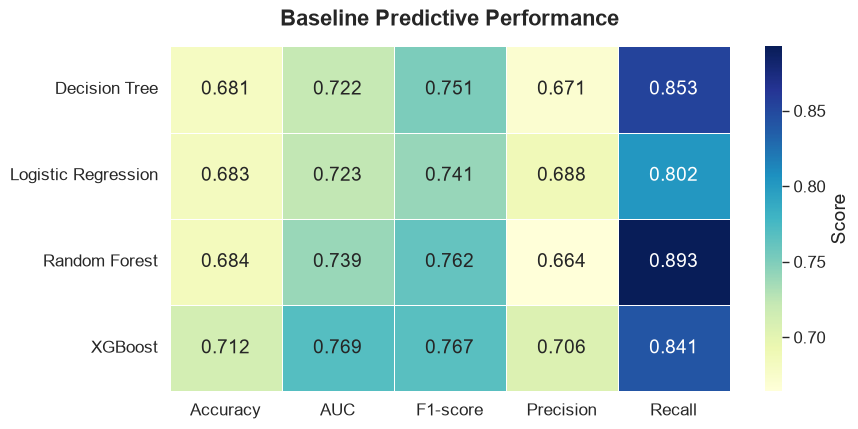

In [7]:
means = (
    df.groupby('Model')[metrics_cols]
      .mean()
)

means = means.rename(
    index={
        'DT': 'Decision Tree',
        'LR': 'Logistic Regression',
        'RF': 'Random Forest',
        'XGB': 'XGBoost'
    }
)

sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.4
)

plt.figure(figsize=(9, 4.5))

ax = sns.heatmap(
    means,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Score'}
)

ax.set_xlabel('')
ax.set_ylabel('')

plt.title(
    'Baseline Predictive Performance',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    'outputs/GreenAI_Outputs/Baseline_Heatmap.pdf',
    bbox_inches='tight'
)

plt.show()

## 7. Heatmaps de Performance Preditiva (DIR)
Gera os heatmaps baseados no seu script para os 5 casos de remoção de features (DIR).

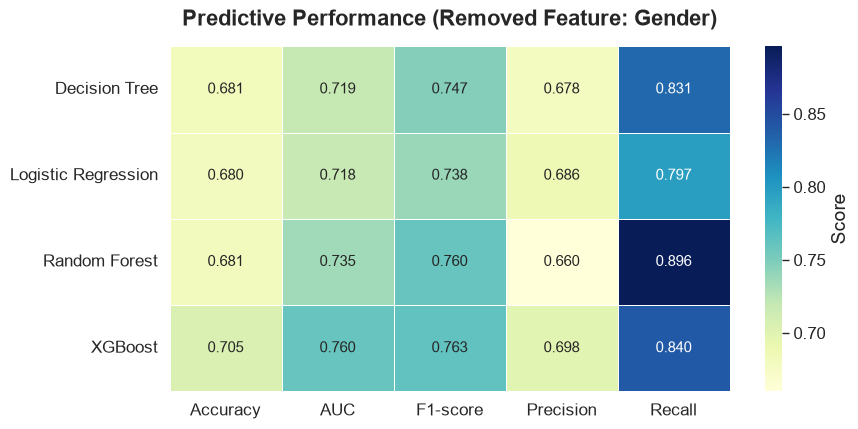

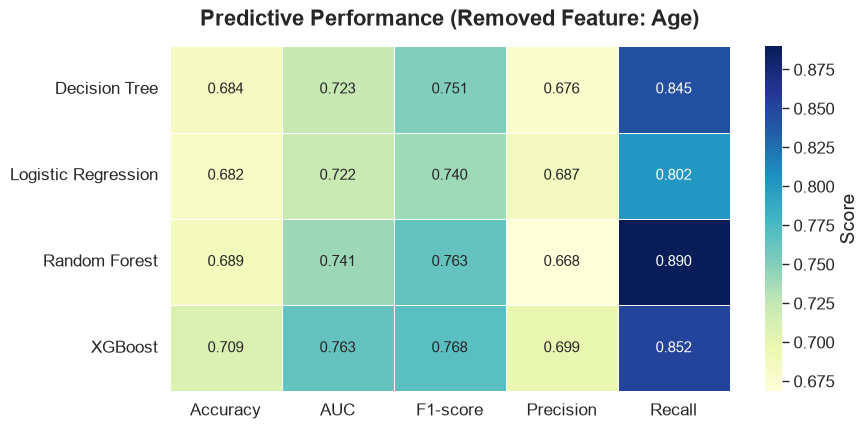

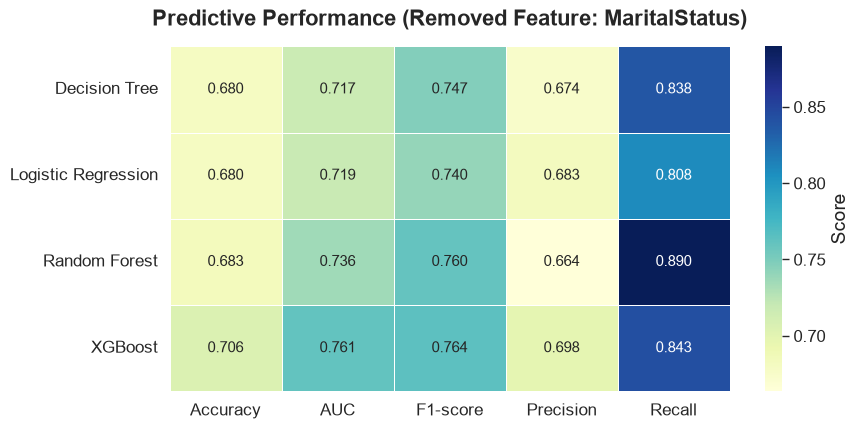

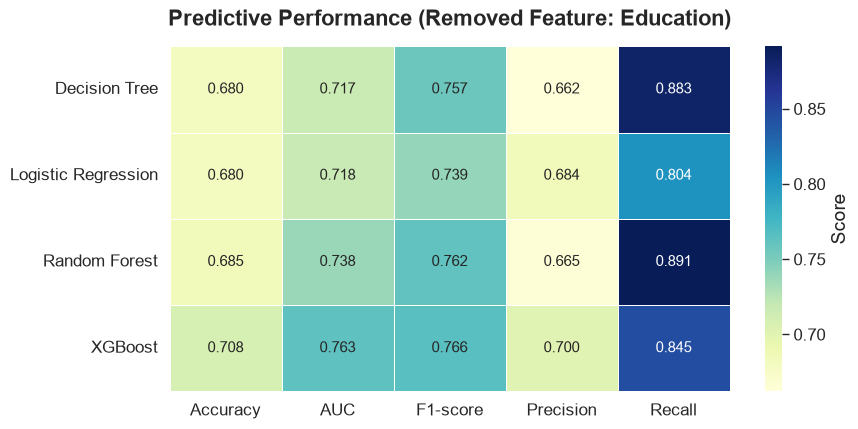

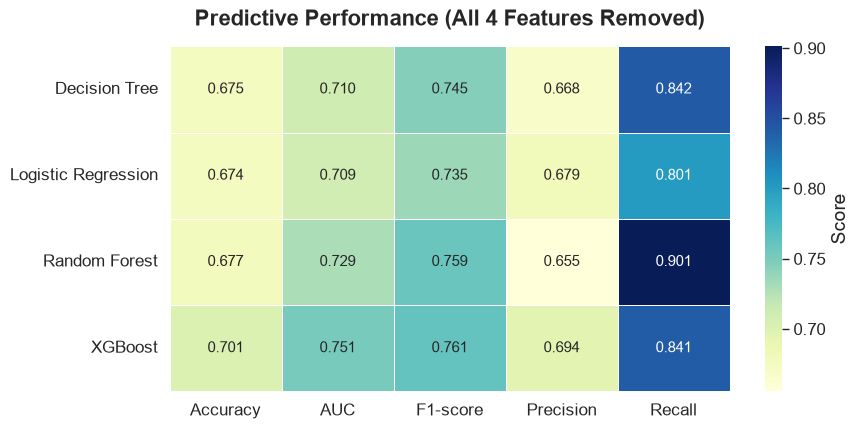

In [8]:
df_dir = pd.read_csv('outputs/DIR_Outputs/dir_performance_global.csv')

df_dir = df_dir.rename(columns={'F1 Score': 'F1-score'})

features = df_dir['Feature'].unique()

model_order = [
    'Decision Tree',
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]

metric_order = [
    'Accuracy',
    'AUC',
    'F1-score',
    'Precision',
    'Recall'
]

sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.4
)

for feat in features:

    df_feat = (
        df_dir[df_dir['Feature'] == feat]
        .set_index('Model')
    )

    df_feat = df_feat.reindex(model_order)
    df_feat = df_feat[metric_order]

    plt.figure(figsize=(9, 4.5))

    ax = sns.heatmap(
        df_feat,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Score'},
        annot_kws={'size': 11}
    )

    ax.set_xlabel('')
    ax.set_ylabel('')

    title_feat = (
        'All 4 Features Removed'
        if feat == 'All'
        else f'Removed Feature: {feat}'
    )

    plt.title(
        f'Predictive Performance ({title_feat})',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.tight_layout()

    plt.savefig(
        f'outputs/DIR_Outputs/DIR_Heatmap_{feat}.pdf',
        bbox_inches='tight'
    )


    plt.show()

## 8. Geração da Tabela LaTeX de Fairness (DIR)
Gera a tabela completa de métricas de fairness com todas as 6 colunas, formatada em LaTeX.

In [9]:
df_fairness = pd.read_csv('outputs/DIR_Outputs/dir_fairness_global.csv')

metrics = ['Disparate Impact Ratio', 'Statistical Parity Diff', 'Equal Opp. Diff', 'Error Rate Gap', 'FPR Gap', 'FNR Gap']
ideals = {'Disparate Impact Ratio': 1.0, 'Statistical Parity Diff': 0.0, 'Equal Opp. Diff': 0.0, 'Error Rate Gap': 0.0, 'FPR Gap': 0.0, 'FNR Gap': 0.0}

# Encontrar o melhor modelo para cada Feature (baseado na distância para o valor ideal)
best_idx = {}
for metric in metrics:
    df_fairness[f'dist_{metric}'] = (df_fairness[metric] - ideals[metric]).abs()
    best_idx[metric] = df_fairness.groupby('Feature')[f'dist_{metric}'].idxmin().values

# Formatar os valores (6 casas decimais e negrito para os melhores)
for metric in metrics:
    formatted_col = []
    for idx, row in df_fairness.iterrows():
        val_str = f"{row[metric]:.6f}"
        if idx in best_idx[metric]:
            val_str = f"\\textbf{{{val_str}}}"
        formatted_col.append(val_str)
    df_fairness[f'{metric}_str'] = formatted_col

models = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'XGBoost']
features_single = ['Gender', 'Age', 'MaritalStatus', 'Education']
features_all = ['All (Gender)', 'All (Age)', 'All (MaritalStatus)', 'All (Education)']

latex = []
latex.append("\\begin{table}[hbt!]")
latex.append("\\centering")
latex.append("\\caption{Quantitative group-level fairness metrics across protected attributes.}")
latex.append("\\label{tab:fairness_metrics}")
latex.append("\\resizebox{\\textwidth}{!}{%")
latex.append("\\begin{tabular}{lllrrrrrr}")
latex.append("\\toprule")
latex.append(" &  &  & Disparate & Statistical & Equal Opp. & Error Rate & FPR & FNR \\\\")
latex.append("Setup & Model & Evaluated Feature & Impact Ratio & Parity Diff & Diff & Gap & Gap & Gap \\\\")
latex.append("\\midrule")

# Single Feature
latex.append("\\multirow{16}{*}{Single Feature} ")
for i, model in enumerate(models):
    if i > 0:
        latex.append("\\cline{2-9}")
    for j, feat in enumerate(features_single):
        row = df_fairness[(df_fairness['Model'] == model) & (df_fairness['Feature'] == feat)]
        if len(row) > 0:
            vals = [row.iloc[0][f'{m}_str'] for m in metrics]
        else:
            vals = ['N/A'] * len(metrics)
        
        if j == 0:
            model_str = f'\\multirow{{4}}{{*}}{{{model}}}'
        else:
            model_str = ''
            
        latex.append(f' & {model_str} & {feat} & ' + ' & '.join(vals) + ' \\\\')

latex.append("\\midrule")

# All Features
latex.append("\\multirow{16}{*}{All Features} ")
for i, model in enumerate(models):
    if i > 0:
        latex.append("\\cline{2-9}")
    for j, feat in enumerate(features_all):
        row = df_fairness[(df_fairness['Model'] == model) & (df_fairness['Feature'] == feat)]
        if len(row) > 0:
            vals = [row.iloc[0][f'{m}_str'] for m in metrics]
        else:
            vals = ['N/A'] * len(metrics)
        
        feat_name = feat.replace('All (', '').replace(')', '')
        if j == 0:
            model_str = f'\\multirow{{4}}{{*}}{{{model}}}'
        else:
            model_str = ''
            
        latex.append(f' & {model_str} & {feat_name} & ' + ' & '.join(vals) + ' \\\\')

latex.append("\\bottomrule")
latex.append("\\end{tabular}%")
latex.append("}")
latex.append("\\end{table}")

print('\n'.join(latex))


\begin{table}[hbt!]
\centering
\caption{Quantitative group-level fairness metrics across protected attributes.}
\label{tab:fairness_metrics}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllrrrrrr}
\toprule
 &  &  & Disparate & Statistical & Equal Opp. & Error Rate & FPR & FNR \\
Setup & Model & Evaluated Feature & Impact Ratio & Parity Diff & Diff & Gap & Gap & Gap \\
\midrule
\multirow{16}{*}{Single Feature} 
 & \multirow{4}{*}{Decision Tree} & Gender & 1.420760 & 0.280289 & 0.145597 & -0.066688 & 0.420970 & -0.145597 \\
 &  & Age & \textbf{0.868804} & -0.099400 & \textbf{-0.060742} & 0.023237 & -0.093426 & \textbf{0.060742} \\
 &  & MaritalStatus & 0.319867 & -0.503240 & -0.443387 & -0.029889 & -0.426710 & 0.443387 \\
 &  & Education & \textbf{0.813594} & \textbf{-0.160715} & \textbf{-0.069834} & 0.028811 & \textbf{-0.205554} & \textbf{0.069834} \\
\cline{2-9}
 & \multirow{4}{*}{Random Forest} & Gender & \textbf{1.335840} & \textbf{0.249868} & \textbf{0.114710} & -0.078851 & \textbf{0